In [1]:
# import os
# from time import time
# import pickle
# from typing import Dict
# import wandb
# import torch

# def format_state_dict(state_dict: Dict) -> Dict:
#     """The `state_dict` saved in checkpoints will have keys with the form:
#         "nn_model.module_list.0.M", "nn_model.module_list.0.M_inv", ...

#     This function updates them to the expected format below. (note the 'nn_model' prefix is removed)
#         "module_list.0.M", "module_list.0.M_inv", ...
#     """
#     bad_prefix = "nn_model."
#     len_prefix = len(bad_prefix)
#     updated = {}
#     for k, v in state_dict.items():
#         # Check that the original state dict is malformatted first
#         assert k[0:len_prefix] == bad_prefix
#         k_new = k[len_prefix:]
#         updated[k_new] = v
#     return updated

# wandb_run_id = "fdeewv8b"
# wandb_entity, wandb_project = ("lunatictang06-massachusetts-institute-of-technology", "ikflow")
# os.environ["WANDB_API_KEY"] = "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"

# api = wandb.Api()
# artifact = api.artifact(f"{wandb_entity}/{wandb_project}/model-{wandb_run_id}:v16")
# download_dir = artifact.download()
# run = api.run(f"/{wandb_entity}/{wandb_project}/runs/{wandb_run_id}")
# run_name = run.name
# robot_name = run.config["robot"]
# ckpt_filepath = os.path.join(download_dir, "model.ckpt")
# checkpoint = torch.load(ckpt_filepath, map_location=lambda storage, loc: storage)
# state_dict = format_state_dict(checkpoint["state_dict"])
# global_step = str(checkpoint["global_step"] / 1e6) + "M"


# model_state_dict_filepath = os.path.join(f"{robot_name}__{run_name}__global_step={global_step}.pkl")
# with open(model_state_dict_filepath, "wb") as f:
#     pickle.dump(state_dict, f)



In [2]:
from ikflow.model import IkflowModelParameters
from ikflow.ikflow_solver import IKFlowSolver
from jrl.robots import get_robot

hparams = {'nb_nodes': 12, 
 'dim_latent_space': 8, 
 'coeff_fn_config': 3, 
 'coeff_fn_internal_size': 1024, 
 'rnvp_clamp': 2.5, 
 'robot_name': 'iiwa14'}


robot = get_robot(hparams['robot_name'])
hyper_parameters = IkflowModelParameters()
hyper_parameters.__dict__.update(hparams)
ik_solver = IKFlowSolver(hyper_parameters, robot, compile_model=None)
ik_solver.load_state_dict("iiwa14__lemon-haze-7__global_step_4.25M.pkl")


ikflow/config.py | Using device: 'cuda:0'
WorldModel::LoadRobot: /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf
URDFParser: Link size: 11
URDFParser: Joint size: 11
URDFParser: Done loading robot file /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf
Initialized robot collision data structures in time 0.243159


In [3]:
import numpy as np
import sys, os
from time import sleep
import torch
from ikflow.config import DEVICE



from pydrake.all import (
    StartMeshcat, 
    RigidTransform,
    Quaternion,
)

sys.path.append(os.path.abspath(os.path.join(os.curdir, '..')))
from src.utils import BuildEnv, RepoDir, DrawAxes, CalculateError
meshcat = StartMeshcat()


diagram = BuildEnv(meshcat=meshcat, directives_file = os.path.join(RepoDir(), "models/iiwa14/iiwa14_collision.yaml"))
plant = diagram.GetSubsystemByName("plant")
diagram_context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(diagram_context)
diagram.ForcedPublish(diagram_context)
frame = plant.GetBodyByName("hand").body_frame()
arm = plant.GetBodyByName("iiwa_link_7")
diagram.ForcedPublish(diagram_context)


INFO:drake:Meshcat listening for connections at http://localhost:7000


In [4]:
latent = torch.tensor(np.random.randn(1,ik_solver.network_width), device=DEVICE, dtype=torch.float32) 
T = RigidTransform(np.array([[0, 0, 1, -0.1],[1, 0, 0, 0],[0, 1, 0, 0],[0, 0, 0, 1]]))

def get_ik_solution(target_pose, latent = None):
    '''
    Computes IK solution using IKFlow, and visualizes target pose in MeshCat in Drake
        Target Pose is numpy array of shape (7,) in the format [x y z qw qx qy qz]'''
    target_pose = torch.tensor(
        target_pose, device=DEVICE
    )
    conditional = torch.cat([target_pose.unsqueeze(0), torch.zeros((1, 1), dtype=torch.float32, device=DEVICE)], dim=1)
    sol = ik_solver.nn_model(latent, c=conditional, rev=True)
    q = np.zeros(plant.num_positions())
    q[:7] = sol[0][0].detach().cpu().numpy()[:7]
    plant.SetPositions(plant_context, q)
    diagram.ForcedPublish(diagram_context)

    pose = target_pose.detach().cpu().numpy()
    pose = RigidTransform(Quaternion(pose[3], pose[4], pose[5], pose[6]), [pose[0], pose[1], pose[2]])
    T_gripper = pose.multiply(T.inverse())
    error = CalculateError(arm.EvalPoseInWorld(plant_context), pose)

    DrawAxes(T_gripper, meshcat)
    return q, error

In [7]:
latent = torch.tensor(np.random.randn(1,ik_solver.network_width), device=DEVICE, dtype=torch.float32) 
start = np.array([0.5, 0.5, 0.5, 1, 0, 0, 0], dtype=np.float32)
end = np.array([-0.5, 0.5, 0.5, -0.6, 0.48, 0.64, 0], dtype=np.float32)

# Linear interpolation for position (first 3)
# SLERP for quaternion (last 4)
t = np.linspace(0, 1, 1000, dtype=np.float32)

pos_start, quat_start = start[:3], start[3:]
pos_end, quat_end = end[:3], -end[3:]

positions = np.outer(1-t, pos_start) + np.outer(t, pos_end)

angle = np.arccos(np.clip(np.dot(quat_start, quat_end), -1, 1))
quats = np.array([
    (np.sin((1-ti)*angle) * quat_start + np.sin(ti*angle) * quat_end) / np.sin(angle)
    for ti in t
])

samples = np.hstack([positions, quats])

angle_errors = []
distance_errors = []
for sample in samples:
    q, error = get_ik_solution(target_pose=sample, latent=latent)
    angle_errors.append(error[0])
    distance_errors.append(error[1])

print(np.mean(angle_errors))
print(np.mean(distance_errors))


0.1336536295366676
0.050703061905920506


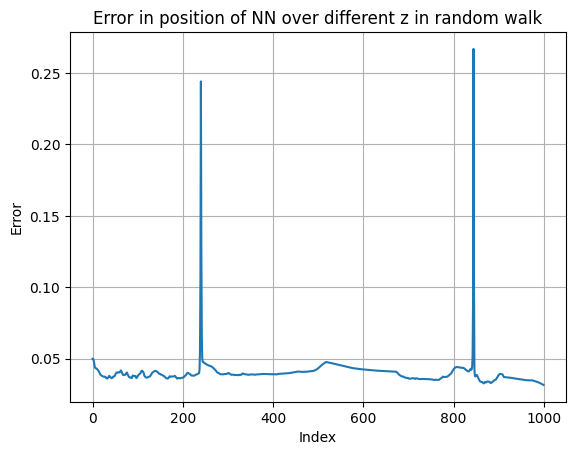

In [10]:
### QUESTION 2: Is the model roughly continuous in latent space for the same target pose?
target_pose = np.array([0.5, 0.5, 0.5, 1, 0, 0, 0], dtype=np.float32)

def hit_and_run_ball_small_steps(n_samples, dim=8, radius=1.5, step_size=0.1, x0=None):
    if x0 is None:
        x0 = np.zeros(dim, dtype=np.float32)
    
    samples = [x0]
    x = x0.copy()
    
    while len(samples) < n_samples:
        # Random direction
        direction = np.random.randn(dim).astype(np.float32)
        direction /= np.linalg.norm(direction)
        
        # Find max step along direction
        a = np.float32(1.0)
        b = np.float32(2.0) * np.dot(x, direction)
        c = np.dot(x, x) - np.float32(radius**2)
        discriminant = b**2 - np.float32(4.0)*a*c
        t_max = (-b + np.sqrt(discriminant)) / (np.float32(2.0)*a)
        t_min = (-b - np.sqrt(discriminant)) / (np.float32(2.0)*a)
        
        # Sample point on line
        t_end = np.float32(np.random.uniform(t_min, t_max))
        
        # Take small steps along line
        n_steps = int(abs(t_end) / step_size) + 1
        for t in np.linspace(0, t_end, n_steps, dtype=np.float32):
            x_new = x + t * direction
            samples.append(x_new.copy())
            if len(samples) >= n_samples:
                break
        
        x = samples[-1]
    
    return np.array(samples[:n_samples], dtype=np.float32)

# Usage
samples = hit_and_run_ball_small_steps(1000, dim=8, step_size=0.005)


errors = []
for sample in samples:
    get_ik_solution(target_pose=target_pose, latent=torch.tensor(sample.reshape(1,8), device=DEVICE, dtype=torch.float32))
    real_pose = frame.CalcPoseInWorld(plant_context)

    errors.append(np.linalg.norm(real_pose.translation() - target_pose[:3]))
    
    sleep(0.01)

import matplotlib.pyplot as plt

plt.plot(errors)
plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Error in position of NN over different z in random walk')
plt.grid(True)
plt.show()
